# Image to LaTeX -- EASY TO USE BATTERY INCLUDED :)

## 1. Mount Google Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision matplotlib nltk Pillow distance -q

## 2. Load Project From google drive


In [2]:
# === 2. RUN AFTER EVERY RUNTIME RESET ===

!mkdir -p /content/CV_220704007

# Copy .py files (tiny, instant)
!cp /content/drive/MyDrive/CV_220704007/*.py /content/CV_220704007/

# Copy zip + extract to local SSD (fast — one big file, -o = overwrite without asking)
!cp /content/drive/MyDrive/CV_220704007/Data_Im2Latx.zip /content/
!unzip -qo /content/Data_Im2Latx.zip -d /content/CV_220704007/
!rm /content/Data_Im2Latx.zip

# Restore checkpoints from Drive if they exist (resume training)
import os, shutil
drive_ckpt = '/content/drive/MyDrive/CV_220704007/checkpoints'
local_ckpt = '/content/CV_220704007/checkpoints'
if os.path.exists(drive_ckpt):
    os.makedirs(local_ckpt, exist_ok=True)
    for f in os.listdir(drive_ckpt):
        shutil.copy2(os.path.join(drive_ckpt, f), local_ckpt)
    print('Restored checkpoints from Drive!')
    !ls -la {local_ckpt}
else:
    print('No checkpoints found on Drive at:', drive_ckpt)

# Also copy vocab.pkl if it exists (avoids rebuilding)
drive_vocab = '/content/drive/MyDrive/CV_220704007/vocab.pkl'
if os.path.exists(drive_vocab):
    shutil.copy2(drive_vocab, '/content/CV_220704007/')
    print('Restored vocab.pkl from Drive!')

%cd /content/CV_220704007
!ls

## 3. Check GPU

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## 4. Check Dataset

In [4]:
import os
data_dir = "Data_Im2Latx"
print("Dataset contents:")
for item in os.listdir(data_dir):
    full = os.path.join(data_dir, item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print("  {}/  ({} files)".format(item, n))
    else:
        sz = os.path.getsize(full)
        print("  {}  ({:.1f} KB)".format(item, sz/1024))

## 5. Build Vocabulary

In [5]:
!python vocab.py

## 6. Train (with attention)
This takes ~1-2 hours on a T4 GPU.

In [ ]:
!python train.py

# Auto-save checkpoints to Drive after training
import shutil, os
save_dir = '/content/drive/MyDrive/CV_220704007/checkpoints'
os.makedirs(save_dir, exist_ok=True)
if os.path.exists('checkpoints'):
    shutil.copytree('checkpoints', save_dir, dirs_exist_ok=True)
    print('Checkpoints saved to Drive!')

## 7. View Training Plots

--- Loss ---


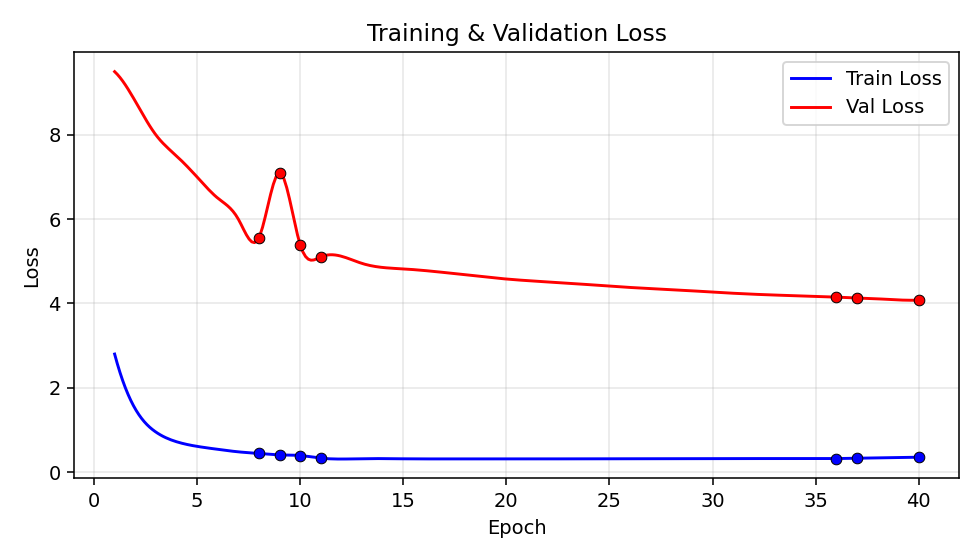

--- BLEU ---


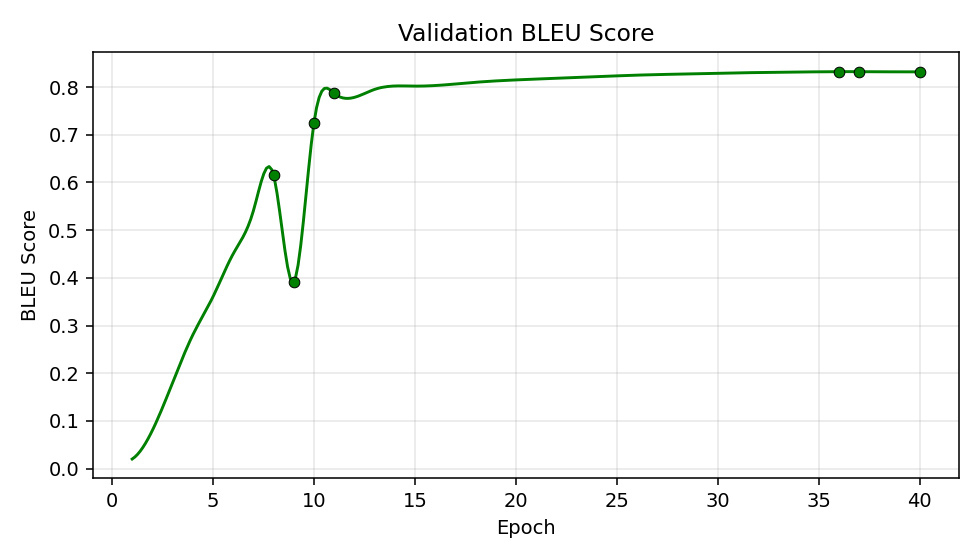

--- Edit Distance ---


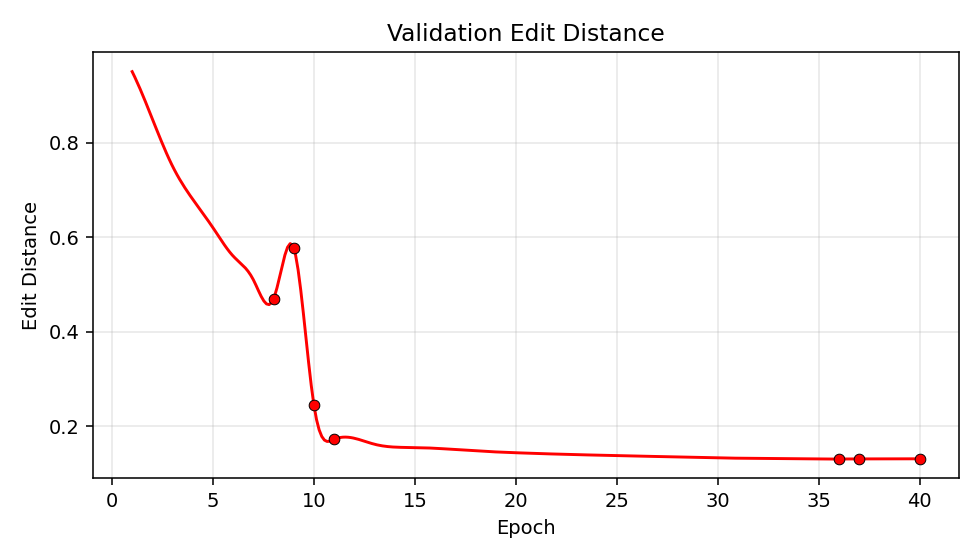

In [1]:
from IPython.display import Image, display
print("--- Loss ---")
display(Image("plots/loss.png"))
print("--- BLEU ---")
display(Image("plots/bleu.png"))
print("--- Edit Distance ---")
display(Image("plots/edit_distance.png"))

## 8. Generate Test Predictions (beam search + post-processing)

In [ ]:
!python predict.py --beam --postprocess

## 9. Preview Predictions

In [1]:
with open("test_formulas.txt", "r") as f:
    lines = f.readlines()
print("Total predictions:", len(lines))
print("\nFirst 10:")
for i, line in enumerate(lines[:10]):
    print("  [{}] {}".format(i, line.strip()))

Total predictions: 10355

First 10:
  [0] \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \ldots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . , R ) \ ,
  [1] \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 b _ { 0 } } \sqrt { 1 + \alpha ^ { 2 } } y - \operatorname { a r c s i n h } \alpha \right) } { \sqrt { 1 + \alpha ^ { 2 } }})
  [2] P _ { ( 2 ) } ^ { - } = \int \beta d \beta d ^ { 2 } p d ^ { 4 } \lambda \Phi ( - p , - \lambda ) \left( - \frac { p ^ { \prime } p ^ { \prime } } { 2 \beta } \right) \Phi ( p , \lambda ) \, .
  [3] \Gamma ( z + 1 ) = \int _ { 0 } ^ { \infty } \ d x \ e ^ { - x } x ^ { z } .
  [4] \frac { d } { d s } { \bf C } _ { i } = \frac { 1 } { 2 } \epsilon _ { i j k } { \bf C } _ { j } \times { \bf C } _ { k } \, .
  [5] Z = \sum _ { s p i n s s c e s s } W ( a | e , f g | b , c , d | h ) ,
  [6] \left\{ Q ^ { i } , Q ^ { j } \right\} = c ^ { i j } \Gamma ^ { M } C P _ { M } + C c ^ { i j } Z ,

## 10. Evaluate Test Predictions (BLEU + Edit Distance)
Checks if test ground truth exists, then runs both metrics.

In [10]:
import os

test_gt = "Data_Im2Latx/test_formulas.txt"
predicted = "test_formulas.txt"

if os.path.exists(test_gt):
    print("=== Test Set BLEU (4-gram) ===")
    !python bleu_score.py --target-formulas {test_gt} --predicted-formulas {predicted} --ngram 4

    print("\n=== Test Set Edit Distance ===")
    !python edit_distance.py --target-formulas {test_gt} --predicted-formulas {predicted}
else:
    print("No test ground truth found at:", test_gt)
    print("Skipping test evaluation. Will evaluate on validation set instead.")

    if os.path.exists("val_predictions.txt"):
        print("\n=== Validation Set BLEU (4-gram) ===")
        !python bleu_score.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt --ngram 4
        print("\n=== Validation Set Edit Distance ===")
        !python edit_distance.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt
    else:
        print("val_predictions.txt not generated yet. Run cell 13 first, then re-run this cell.")

No test ground truth found at: Data_Im2Latx/test_formulas.txt
Skipping test evaluation. Will evaluate on validation set instead.

=== Validation Set BLEU (4-gram) ===
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
2000/8370
4000/8370
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_sc

## 11. Evaluate on Validation Set
Uses the provided evaluation scripts.

In [ ]:
# first generate val predictions (beam search + postprocessing, same as test)
import config as C
import torch
from torch.utils.data import DataLoader
from vocab import Vocab
from dataset import FormulaDataset, collate_train
from model import Im2Latex
from postprocess import clean_latex

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab = Vocab.load()
ckpt = torch.load("checkpoints/model_best.pt", map_location=dev)
model = Im2Latex(ckpt["vocab_size"]).to(dev)
model.load_state_dict(ckpt["model"])
model.eval()

val_ds = FormulaDataset(
    C.VAL_IMAGES_DIR, C.VAL_FORMULAS, vocab, training=False)
val_ld = DataLoader(val_ds, C.BATCH, shuffle=False, collate_fn=collate_train)

val_preds = []
done = 0
total = len(val_ds)
for imgs, tgts, lens in val_ld:
    done += imgs.size(0)
    print("\r  {}/{} images ({:.0f}%)".format(done,
          total, 100*done/total), end="", flush=True)
    imgs = imgs.to(dev)
    seqs = model.beam_decode(imgs, vocab.sos_id, vocab.eos_id, beam_k=C.BEAM_K)
    for seq in seqs:
        formula = " ".join(vocab.decode(seq))
        formula = clean_latex(formula)
        val_preds.append(formula)

print()
with open("val_predictions.txt", "w") as f:
    for p in val_preds:
        f.write(p + "\n")
print("Wrote {} val predictions (beam + postprocess)".format(len(val_preds)))

Loaded vocab (544 tokens) <- /home/hasan/Desktop/CV_220704007/vocab.pkl
[FormulaDataset] 8370 samples from /home/hasan/Desktop/CV_220704007/Data_Im2Latx/images_val
  8370/8370 images (100%)
Wrote 8370 val predictions


In [15]:
print("=== BLEU ===")
!python bleu_score.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt --ngram 4

print("\n=== Edit Distance ===")
!python edit_distance.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt

=== BLEU ===
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
2000/8370
4000/8370
/home/hasan/Desktop/CV_220704007/venv/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram o

## 12. Visual Comparison: Image vs Prediction vs Ground Truth
Shows 8 random validation samples side by side. Each row: the input image, the ground truth LaTeX, and the model's prediction.

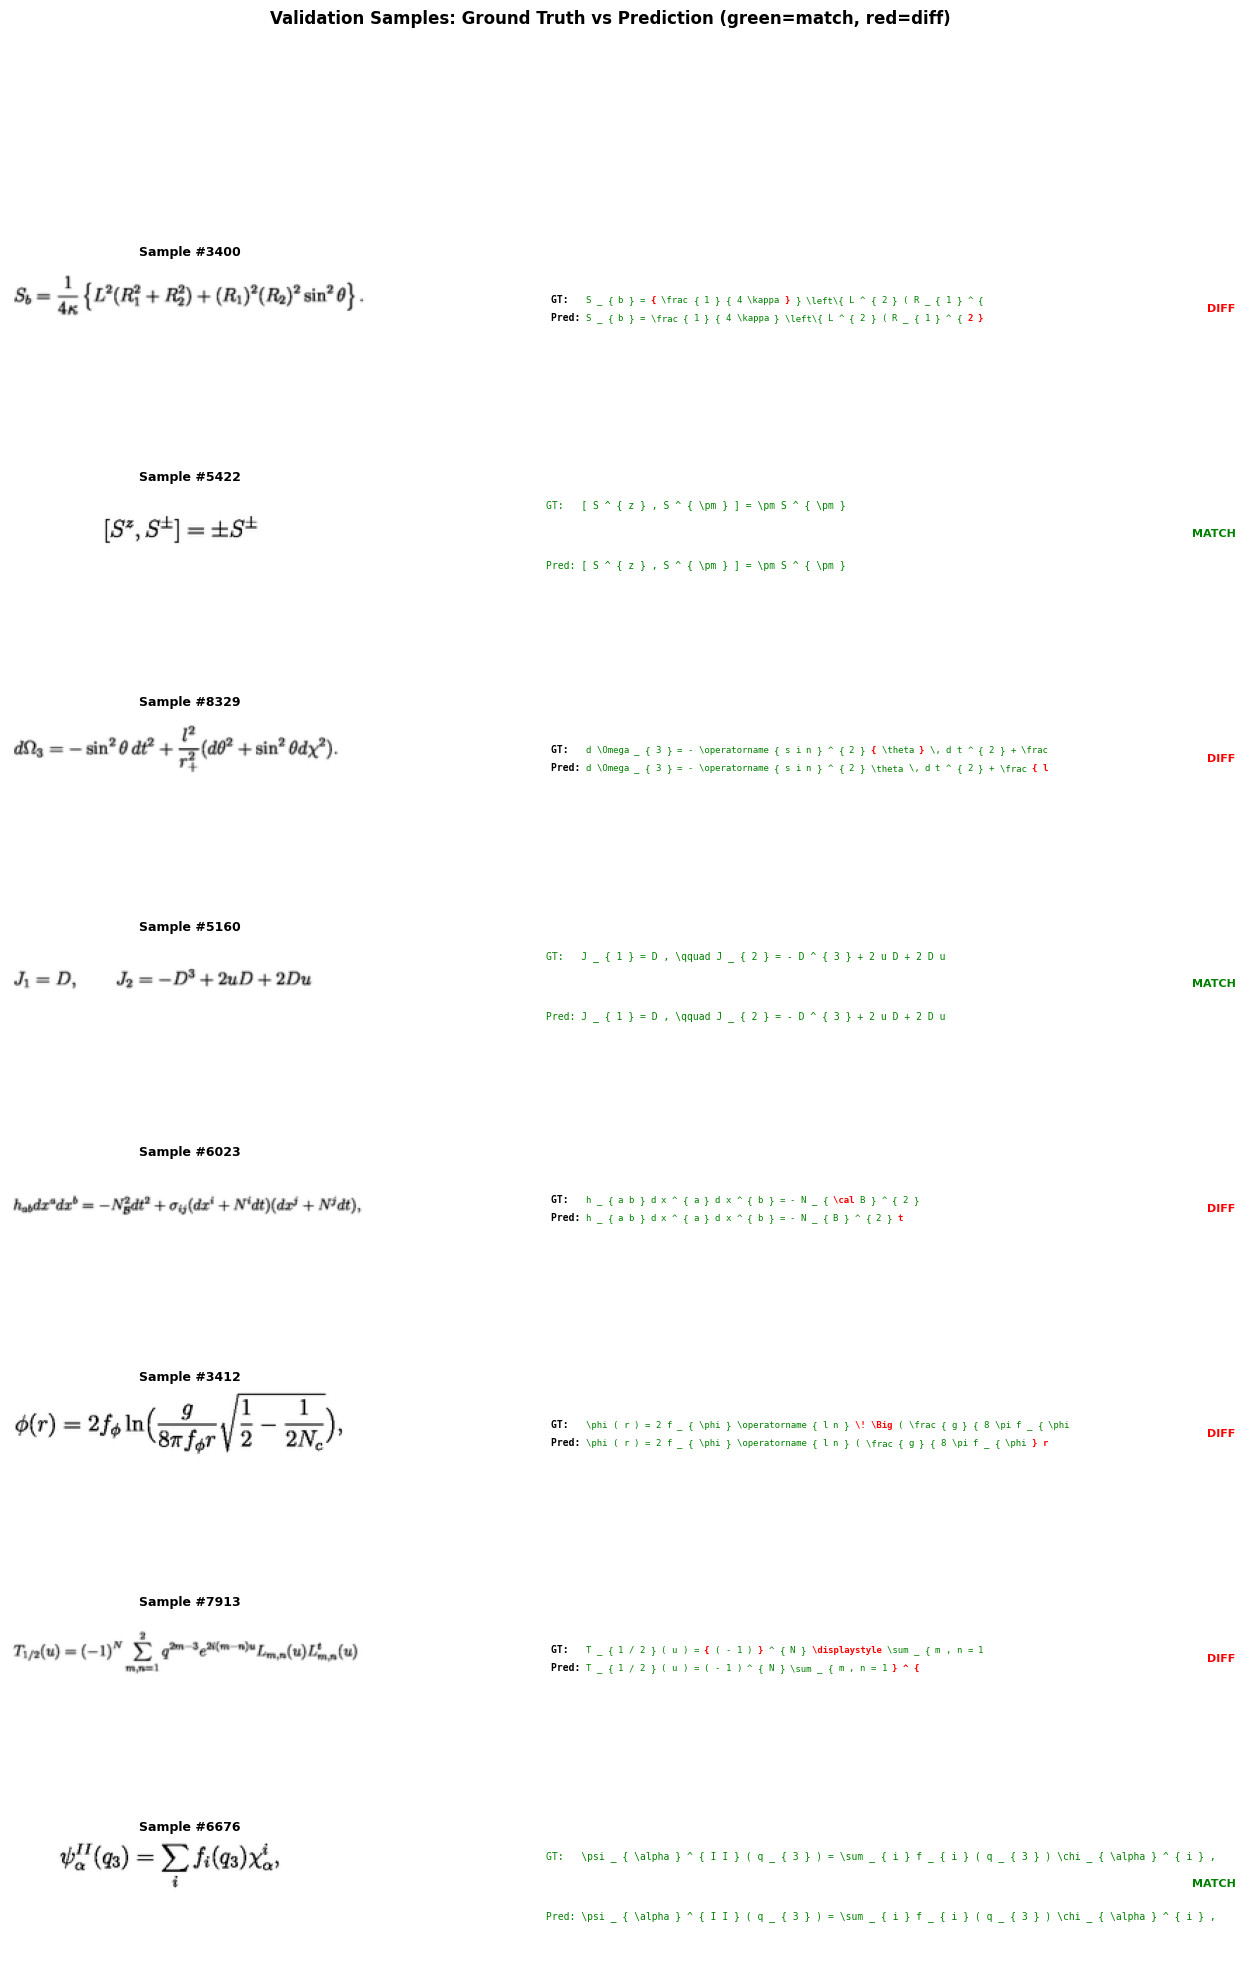

Saved comparison plot to plots/comparison.png


In [14]:
import random
import difflib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import HPacker, TextArea, AnchoredOffsetbox, VPacker
from PIL import Image as PILImage
import config as C
from vocab import read_formulas

# Load ground truth and predictions
gt_formulas = read_formulas(C.VAL_FORMULAS)
with open("val_predictions.txt", "r") as f:
    pred_formulas = [line.strip().split() for line in f.readlines()]

# Pick 8 random samples
num_samples = 8
indices = random.sample(range(len(gt_formulas)), num_samples)

fig = plt.figure(figsize=(16, num_samples * 2.8))
gs = gridspec.GridSpec(num_samples, 2, width_ratios=[
                       1, 2], hspace=0.5, wspace=0.3)


def build_diff_boxes(gt_tokens, pred_tokens, fontsize=6.5):
    """Return (gt_boxes, pred_boxes) with matching tokens green, diffs red."""
    sm = difflib.SequenceMatcher(None, gt_tokens, pred_tokens)
    gt_boxes = []
    pred_boxes = []
    for op, i1, i2, j1, j2 in sm.get_opcodes():
        if op == "equal":
            for t in gt_tokens[i1:i2]:
                gt_boxes.append(TextArea(
                    t + " ", textprops=dict(fontsize=fontsize, fontfamily="monospace", color="green")))
            for t in pred_tokens[j1:j2]:
                pred_boxes.append(TextArea(
                    t + " ", textprops=dict(fontsize=fontsize, fontfamily="monospace", color="green")))
        elif op == "replace":
            for t in gt_tokens[i1:i2]:
                gt_boxes.append(TextArea(t + " ", textprops=dict(fontsize=fontsize,
                                fontfamily="monospace", color="red", fontweight="bold")))
            for t in pred_tokens[j1:j2]:
                pred_boxes.append(TextArea(t + " ", textprops=dict(fontsize=fontsize,
                                  fontfamily="monospace", color="red", fontweight="bold")))
        elif op == "delete":
            for t in gt_tokens[i1:i2]:
                gt_boxes.append(TextArea(t + " ", textprops=dict(fontsize=fontsize,
                                fontfamily="monospace", color="red", fontweight="bold")))
        elif op == "insert":
            for t in pred_tokens[j1:j2]:
                pred_boxes.append(TextArea(t + " ", textprops=dict(fontsize=fontsize,
                                  fontfamily="monospace", color="red", fontweight="bold")))
    return gt_boxes, pred_boxes


for row, idx in enumerate(indices):
    img_path = os.path.join(C.VAL_IMAGES_DIR, "{:05d}.png".format(idx))
    img = PILImage.open(img_path).convert("L")

    gt_tokens = gt_formulas[idx]
    pred_tokens = pred_formulas[idx] if idx < len(pred_formulas) else ["N/A"]
    match = (gt_tokens == pred_tokens)

    # Left: image
    ax_img = fig.add_subplot(gs[row, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title("Sample #{}".format(idx), fontsize=9, fontweight="bold")
    ax_img.axis("off")

    # Right: colored diff text
    ax_txt = fig.add_subplot(gs[row, 1])
    ax_txt.axis("off")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)

    if match:
        ax_txt.text(0.02, 0.72, "GT:   " + " ".join(gt_tokens)[:120],
                    fontsize=7, fontfamily="monospace", color="green", va="top")
        ax_txt.text(0.02, 0.32, "Pred: " + " ".join(pred_tokens)[:120],
                    fontsize=7, fontfamily="monospace", color="green", va="top")
        ax_txt.text(0.98, 0.5, "MATCH", fontsize=8, fontweight="bold",
                    color="green", ha="right", va="center")
        ax_txt.set_facecolor("#e8f5e9")
    else:
        # Truncate for display
        gt_trunc = gt_tokens[:30]
        pred_trunc = pred_tokens[:30]

        gt_boxes, pred_boxes = build_diff_boxes(gt_trunc, pred_trunc)

        # GT label + tokens
        gt_label = TextArea("GT:   ", textprops=dict(
            fontsize=7, fontfamily="monospace", color="black", fontweight="bold"))
        gt_row = HPacker(children=[gt_label] + gt_boxes,
                         pad=0, sep=0, align="baseline")

        # Pred label + tokens
        pred_label = TextArea("Pred: ", textprops=dict(
            fontsize=7, fontfamily="monospace", color="black", fontweight="bold"))
        pred_row = HPacker(children=[pred_label] +
                           pred_boxes, pad=0, sep=0, align="baseline")

        vbox = VPacker(children=[gt_row, pred_row], pad=2, sep=6, align="left")
        anchored = AnchoredOffsetbox(loc="center left", child=vbox, pad=0.2,
                                     bbox_to_anchor=(0.01, 0.5),
                                     bbox_transform=ax_txt.transAxes, frameon=False)
        ax_txt.add_artist(anchored)

        ax_txt.text(0.98, 0.5, "DIFF", fontsize=8, fontweight="bold",
                    color="red", ha="right", va="center")
        ax_txt.set_facecolor("#fff3e0")

plt.suptitle("Validation Samples: Ground Truth vs Prediction (green=match, red=diff)",
             fontsize=12, fontweight="bold")
plt.savefig("plots/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison plot to plots/comparison.png")

## 13. Save Results to Google Drive

In [ ]:
import shutil, os

save_dir = "/content/drive/MyDrive/CV_220704007"
os.makedirs(save_dir, exist_ok=True)

shutil.copy("test_formulas.txt", save_dir)
shutil.copytree("plots", os.path.join(save_dir, "plots"), dirs_exist_ok=True)
shutil.copytree("checkpoints", os.path.join(save_dir, "checkpoints"), dirs_exist_ok=True)

print("Saved everything to", save_dir)
print("Contents:")
for root, dirs, files in os.walk(save_dir):
    for f in files:
        print("  ", os.path.join(root, f))